In [ ]:
pip install TextBlob

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from textblob import TextBlob

**Polarity** :

 * 1 Positivo

 * 0 Neutro

 * -1 Negativo

**Subjetivity**:

  * 1 Subjetive

  * 0 Objetive

In [ ]:
TextBlob("I hate the sea food").sentiment

Sentiment(polarity=-0.8, subjectivity=0.9)

In [ ]:
TextBlob("I love the sea food").sentiment.polarity

0.5

In [ ]:
TextBlob("I love the sea food").sentiment.subjectivity

0.6

In [ ]:
TextBlob("Odio la comida de mar").sentiment

Sentiment(polarity=0.0, subjectivity=0.0)

In [ ]:
TextBlob("NEGOCIACAO DE TAXA DE JUROS INFLEXIVEL	").translate(from_lang='pt', to='en')

TextBlob("Interest rate trading inflexible")

In [ ]:
s = TextBlob("NEGOCIACAO DE TAXA DE JUROS INFLEXIVEL	").translate(from_lang='pt', to='en').sentiment.polarity
s

-0.4

In [ ]:
comments_restaurant = pd.read_csv("/content/drive/MyDrive/Restaurant_Reviews.tsv",sep='\t')
##comments_restaurant.drop('Liked', axis=1, inplace=True)
comments_restaurant.head()

NameError: ignored

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
comments_restaurant['Review'][1]

'Crust is not good.'

In [ ]:
TextBlob(comments_restaurant['Review'][1]).sentiment.polarity

-0.35

In [ ]:
def get_polarity(text):
  analysis = TextBlob(text).sentiment.polarity
  return analysis

In [ ]:
comments_restaurant["polarity"] = comments_restaurant["Review"].apply(get_polarity)
comments_restaurant["polarity"].head(10)

0    0.40
1   -0.35
2   -1.00
3    0.20
4    0.80
5   -0.50
6    0.30
7    0.00
8    0.80
9    0.80
Name: polarity, dtype: float64

In [ ]:
def x_range(pol):
  if pol >= 0.2 :
    pol = 1
  elif pol < 0.2 and pol >= -0.2:
    pol = 0
  else:
    pol = -1
  return pol

In [ ]:
comments_restaurant["result"] = comments_restaurant["polarity"].apply(x_range)
comments_restaurant["result"].head()

0    1
1   -1
2   -1
3    0
4    1
Name: result, dtype: int64

In [ ]:
comments_restaurant["result"].value_counts()

 1    425
 0    402
-1    173
Name: result, dtype: int64

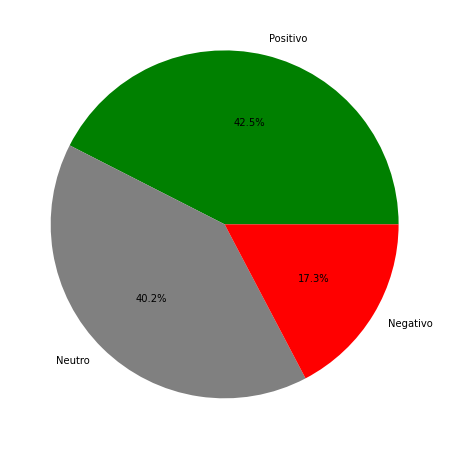

In [ ]:
plt.figure(figsize=(8,8))
labels = 'Positivo', 'Neutro', 'Negativo'
colors = "green", "gray", "red"
plt.pie(comments_restaurant["result"].value_counts(), labels=labels, colors=colors, autopct = '%1.1f%%')
plt.show()

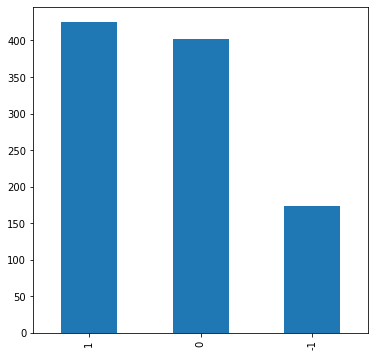

In [ ]:
plt.figure(figsize=(6,6))
comments_restaurant["result"].value_counts().plot.bar()
plt.show()